In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_spin_per_state,
    spectral_function,
)
from alter_morph.lattice_utilities import alter_lattice_maker
from alter_morph.mean_field import hartree_fock

# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [3]:
def fermi_level(energies, filling):
    return np.mean(
        energies[int(filling * len(energies)) - 1 : int(filling * len(energies)) + 1]
    )

In [4]:
system_length = 26
lattice_type = "voronoi"
lattice = alter_lattice_maker(system_length, lattice_type)
# lattice = koala.graph_utils.cut_boundaries(lattice)


t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
J = 0.8  # Interaction strength
U = J  # Density-density interaction
filling = 0.3  # filling of the lattice
initial_m = np.full(lattice.n_vertices, 1) + 0.001 * np.random.rand(lattice.n_vertices)
initial_n = np.full(lattice.n_vertices, filling * 4)
theta_offset = 0.0  # offset of the staggered magnetization
orbital_symmetries = (1, 2, 3, 4)

initial_parameters = {
    "t1": t1,
    "t2": t2,
    "J": J,
    "U": U,
    "filling": filling,
    "initial_m": initial_m,
    "initial_n": initial_n,
    "theta_offset": theta_offset,
}

In [5]:
spectrals = []

for orbital_sym in orbital_symmetries:

    m_values, n_values = hartree_fock(
        lattice,
        initial_parameters,
        100,
        mixing_proportion=0.1,
        tol_mdiff=0.001,
        adjust_learning_rate=True,
        orbital_symmetry=orbital_sym,
    )

    hamiltonian = alt_hamiltonian(
        lattice,
        initial_parameters["t1"],
        initial_parameters["t2"],
        initial_parameters["J"],
        initial_parameters["U"],
        m_values[-1],
        n_values[-1],
        theta_offset=initial_parameters["theta_offset"],
        orbital_symmetry=orbital_sym,
    )
    energies, states = la.eigh(hamiltonian)

    energy_to_look_at = fermi_level(
        energies,
        initial_parameters["filling"],
    )
    broadening = 0.5

    spectrals.append(
        spectral_function(
            lattice,
            energies,
            states,
            energy_to_look_at,
            local_operator=np.array([1, 1, -1, -1]),
            eta=broadening,
            n_k=100,
        )
    )

Avg:1.19, diff: 0.000008:   5%|▌         | 5/100 [00:30<09:35,  6.06s/it]


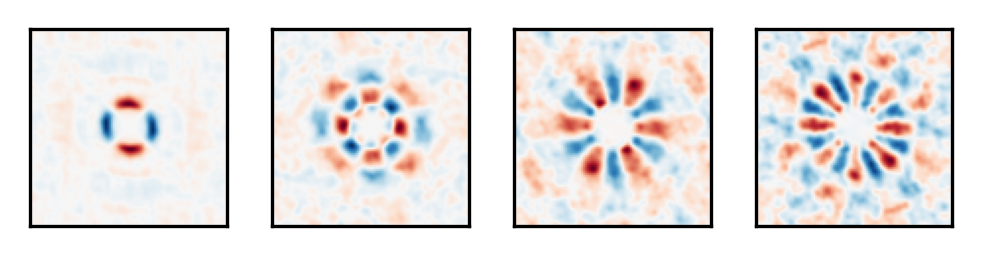

In [7]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(aps_halfwidth, aps_halfwidth / 3.5),
    dpi=300,
    sharex=True,
    sharey=True,
)

for i, a in enumerate(ax):
    a.set_xticks([])
    a.set_yticks([])
    a.set_aspect("equal")

    max_val = np.max(np.abs(spectrals[i]))

    im = a.imshow(
        spectrals[i], cmap="RdBu_r", origin="lower", vmin=-max_val, vmax=max_val
    )

plt.tight_layout()
plt.savefig("paper_figs/higher_order.pdf", transparent=True)